In [1]:
import os
os.chdir("/Users/yesicarb/Desktop/UIE/3º Curso/2 SEM/PROYECTO/emotion/multimodal_emotion")

import json
import numpy as np
import pandas as pd
import sys
sys.path.append("src")

from fusion.late_fusion import run_fusion

df = pd.read_csv("data/processed/labels.csv")

In [2]:
# Necesitamos las etiquetas reales en el mismo orden que las probabilidades
# Las probabilidades se generaron con random_state=42 y stratify
# así que reproducimos el mismo split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le     = LabelEncoder()
labels = le.fit_transform(df['label'].tolist())
texts  = df['text'].tolist()

_, _, _, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"Test set: {len(y_test)} muestras")
print(f"Clases: {le.classes_}")

Test set: 974 muestras
Clases: ['negative' 'neutral' 'positive']


In [3]:
# Celda 2.5 — Buscar pesos óptimos
from itertools import product
from sklearn.metrics import f1_score

def evaluate_weights(w_lr, w_bert, w_svm, w_resnet, probas_list, true_labels):
    weights = np.array([w_lr, w_bert, w_svm, w_resnet])
    weights = weights / weights.sum()
    fusion  = sum(w * p for w, p in zip(weights, probas_list))
    preds   = np.argmax(fusion, axis=1)
    return f1_score(true_labels, preds, average='macro')

# Cargar probabilidades
from fusion.late_fusion import load_probas
paths = [
    'results/metrics_nlp_classic.json',
    'results/metrics_bert.json',
    'results/metrics_cv_classic.json',
    'results/metrics_resnet.json'
]
probas_list = [load_probas(p) for p in paths]
n           = min(len(p) for p in probas_list)
probas_list = [p[:n] for p in probas_list]
y           = y_test[:n]

# Probar combinaciones de pesos
best_f1, best_w = 0, None
opciones = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for w_lr, w_bert, w_svm, w_resnet in product(opciones, repeat=4):
    if w_lr + w_bert + w_svm + w_resnet == 0:
        continue
    f1 = evaluate_weights(w_lr, w_bert, w_svm, w_resnet, probas_list, y)
    if f1 > best_f1:
        best_f1 = f1
        best_w  = (w_lr, w_bert, w_svm, w_resnet)

print(f"Mejores pesos encontrados: LR={best_w[0]}, BERT={best_w[1]}, SVM={best_w[2]}, ResNet={best_w[3]}")
print(f"F1 macro con pesos óptimos: {best_f1:.4f}")

Mejores pesos encontrados: LR=0.6, BERT=0.5, SVM=0.0, ResNet=0.1
F1 macro con pesos óptimos: 0.7369


In [4]:
preds, fusion_probas, f1 = run_fusion(
    true_labels=y_test,
    class_names=le.classes_,
    paths=[
        'results/metrics_nlp_classic.json',
        'results/metrics_bert.json',
        'results/metrics_cv_classic.json',
        'results/metrics_resnet.json'
    ]
)


=== Late Fusion (Agente Multimodal) ===
              precision    recall  f1-score   support

    negative       0.68      0.74      0.71       244
     neutral       0.74      0.71      0.72       384
    positive       0.78      0.78      0.78       346

    accuracy                           0.74       974
   macro avg       0.73      0.74      0.74       974
weighted avg       0.74      0.74      0.74       974

F1 macro: 0.7369


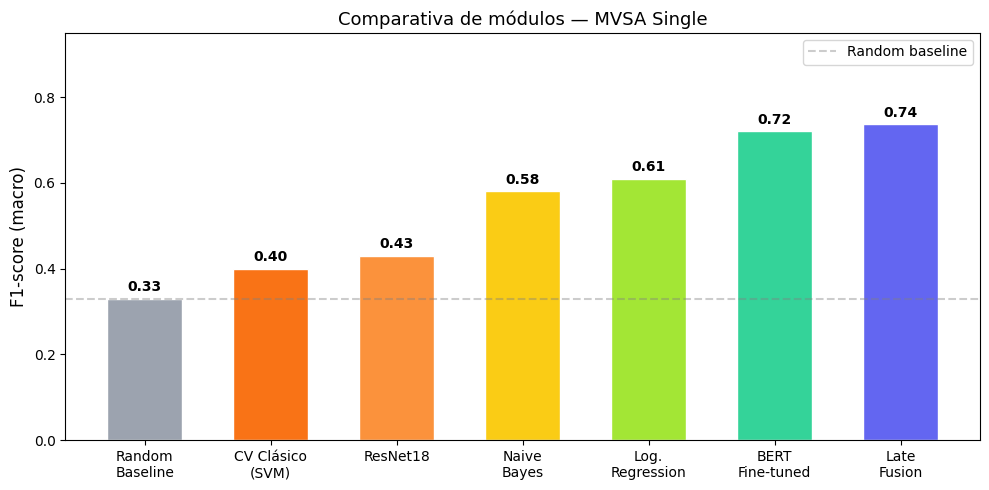

In [5]:
import matplotlib.pyplot as plt

modulos = [
    'Random\nBaseline',
    'CV Clásico\n(SVM)',
    'ResNet18',
    'Naive\nBayes',
    'Log.\nRegression',
    'BERT\nFine-tuned',
    'Late\nFusion'
]
f1_scores = [0.33, 0.40, 0.43, 0.58, 0.61, 0.72, f1]
colors    = [
    '#9ca3af', '#f97316', '#fb923c',
    '#facc15', '#a3e635', '#34d399', '#6366f1'
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(modulos, f1_scores, color=colors, width=0.6, edgecolor='white')

for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 0.95)
ax.set_ylabel('F1-score (macro)', fontsize=12)
ax.set_title('Comparativa de módulos — MVSA Single', fontsize=13)
ax.axhline(y=0.33, color='gray', linestyle='--', alpha=0.4, label='Random baseline')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/fusion_comparison.png', dpi=150)
plt.show()